--- ĐANG ĐỌC DỮ LIỆU TỪ: D:\Code_File\DAV\final project\original_file.csv ---
Đang tổng hợp dữ liệu thô (Aggregation)...
Kích thước dữ liệu Baseline: (160, 16)
Số lượng đặc trưng: 16 (Chỉ gồm Mean, Std, Min, Max)

--- BẮT ĐẦU CHẠY THỬ NGHIỆM 13 MÔ HÌNH ---
Tên Mô Hình               | Accuracy Trung Bình  | Độ Lệch Chuẩn
-----------------------------------------------------------------
Logistic Regression       | 74.38%             | +/- 9.96%
KNN                       | 69.38%             | +/- 8.00%
SVM (RBF)                 | 76.25%             | +/- 9.40%
SVM (Linear)              | 74.38%             | +/- 7.76%
Random Forest             | 71.25%             | +/- 8.00%
Gradient Boosting         | 69.38%             | +/- 11.42%
Extra Trees               | 68.75%             | +/- 8.84%
AdaBoost                  | 68.75%             | +/- 14.39%
XGBoost                   | 70.62%             | +/- 12.28%
LightGBM                  | 65.62%             | +/- 11.52%
MLP (Neural Net)  

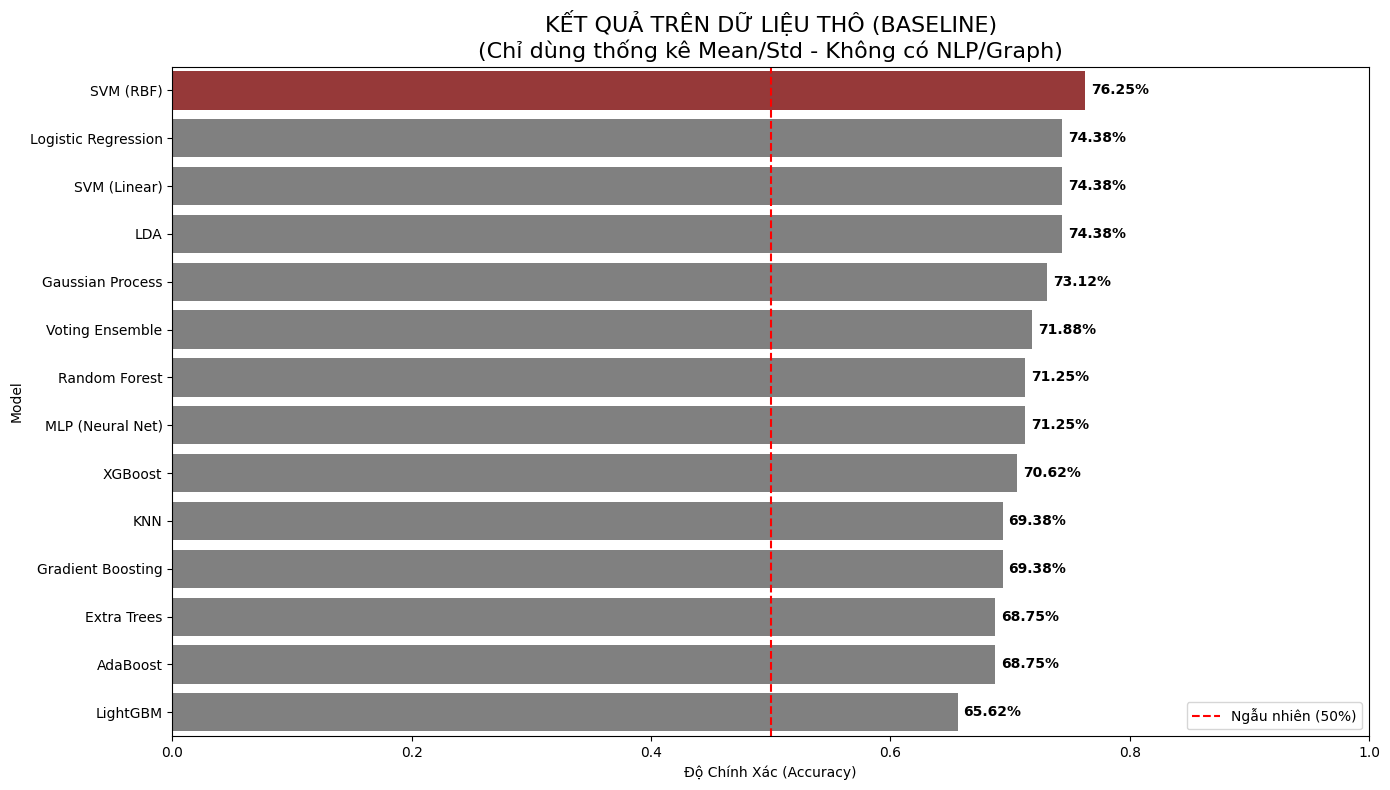


=> Kết luận: So sánh kết quả này với con số 84.38% của phương pháp đề xuất.


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Sklearn imports
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Model imports
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

# 1. ĐỌC DỮ LIỆU GỐC
file_path = 'D:\\Code_File\\DAV\\final project\\original_file.csv'

print(f"--- ĐANG ĐỌC DỮ LIỆU TỪ: {file_path} ---")
try:
    df = pd.read_csv(file_path)
    # Lọc nhiễu cơ bản (tọa độ âm hoặc ngoài màn hình)
    df = df[(df['FIX_X'] >= 0) & (df['FIX_X'] <= 1920) & (df['FIX_Y'] >= 0) & (df['FIX_Y'] <= 1080)]
except Exception as e:
    print(f"Lỗi đọc file: {e}")
    exit()

# 2. XỬ LÝ DỮ LIỆU THÔ (STATISTICAL AGGREGATION)
# Mục tiêu: Chuyển hàng nghìn dòng của 1 người thành 1 dòng duy nhất.
# Cách làm: Tính Mean, Std, Min, Max của tọa độ X, Y, Thời gian.
print("Đang tổng hợp dữ liệu thô (Aggregation)...")

# Định nghĩa cách gộp
aggregations = {
    'FIX_X': ['mean', 'std', 'min', 'max', 'median'],
    'FIX_Y': ['mean', 'std', 'min', 'max', 'median'],
    'FIX_DURATION': ['mean', 'std', 'sum', 'max'],
    'FIX_PUPIL': ['mean', 'std'] if 'FIX_PUPIL' in df.columns else [], # Nếu có cột đồng tử
    'label': 'first' # Nhãn bệnh là cố định cho mỗi người
}

# Nếu không có cột pupil thì bỏ qua
if 'FIX_PUPIL' not in df.columns:
    del aggregations['FIX_PUPIL']

# Thực hiện Groupby
baseline_df = df.groupby('numeric_id').agg(aggregations)

# Làm phẳng tên cột (từ MultiIndex thành SingleIndex)
# Ví dụ: ('FIX_X', 'mean') -> 'FIX_X_mean'
baseline_df.columns = ['_'.join(col).strip() if col[0] != 'label' else 'label' for col in baseline_df.columns.values]
baseline_df.reset_index(inplace=True)

# Tách X và y
X = baseline_df.drop(columns=['numeric_id', 'label'])
y = baseline_df['label']

# Xử lý dữ liệu khuyết (NaN) nếu có (do tính std của 1 dòng sẽ ra NaN)
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Chuẩn hóa dữ liệu (Bắt buộc cho SVM/KNN/MLP)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Kích thước dữ liệu Baseline: {X.shape}")
print(f"Số lượng đặc trưng: {X.shape[1]} (Chỉ gồm Mean, Std, Min, Max)")

# 3. CHẠY BENCHMARK 13 MÔ HÌNH (Đã bỏ CatBoost)
print("\n--- BẮT ĐẦU CHẠY THỬ NGHIỆM 13 MÔ HÌNH ---")

models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('KNN', KNeighborsClassifier(n_neighbors=5)),
    ('SVM (RBF)', SVC(kernel='rbf', probability=True)),
    ('SVM (Linear)', SVC(kernel='linear', probability=True)),
    ('Random Forest', RandomForestClassifier(n_estimators=200, random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=200, random_state=42)),
    ('Extra Trees', ExtraTreesClassifier(n_estimators=200, random_state=42)),
    ('AdaBoost', AdaBoostClassifier(n_estimators=100, random_state=42)),
    ('XGBoost', XGBClassifier(n_estimators=200, eval_metric='logloss', use_label_encoder=False, random_state=42)),
    ('LightGBM', LGBMClassifier(n_estimators=200, verbose=-1, random_state=42)),
    ('MLP (Neural Net)', MLPClassifier(max_iter=1000, random_state=42)),
    ('LDA', LinearDiscriminantAnalysis()),
    ('Gaussian Process', GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42))
]

# Voting Ensemble
voting_clf = VotingClassifier(estimators=[
    ('gb', models[5][1]), ('et', models[6][1]), ('svm', models[2][1])], voting='soft')
models.append(('Voting Ensemble', voting_clf))

results = []
names = []
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Tên Mô Hình':<25} | {'Accuracy Trung Bình':<20} | {'Độ Lệch Chuẩn'}")
print("-" * 65)

for name, model in models:
    try:
        cv_scores = cross_val_score(model, X_scaled, y, cv=kfold, scoring='accuracy')
        acc_mean = cv_scores.mean()
        acc_std = cv_scores.std()
        
        results.append(acc_mean)
        names.append(name)
        
        print(f"{name:<25} | {acc_mean*100:.2f}%             | +/- {acc_std*100:.2f}%")
    except Exception as e:
        print(f"{name:<25} | LỖI: {str(e)}")
        results.append(0)
        names.append(name)

# 4. VẼ BIỂU ĐỒ SO SÁNH
df_res = pd.DataFrame({'Model': names, 'Accuracy': results})
df_res = df_res.sort_values(by='Accuracy', ascending=False)
df_res = df_res[df_res['Accuracy'] > 0]

plt.figure(figsize=(14, 8))
# Màu xám để thể hiện đây là kết quả Baseline (kém hơn)
colors = ['#808080' for _ in range(len(df_res))]
# Tô màu đỏ cho model tốt nhất trong đám này (để dễ nhìn)
colors[0] = '#A52A2A'

ax = sns.barplot(x='Accuracy', y='Model', data=df_res, palette=colors)

for i, v in enumerate(df_res['Accuracy']):
    ax.text(v + 0.005, i, f'{v*100:.2f}%', va='center', fontweight='bold')

plt.title('KẾT QUẢ TRÊN DỮ LIỆU THÔ (BASELINE)\n(Chỉ dùng thống kê Mean/Std - Không có NLP/Graph)', fontsize=16)
plt.xlim(0, 1.0)
plt.xlabel('Độ Chính Xác (Accuracy)')
plt.axvline(x=0.5, color='red', linestyle='--', label='Ngẫu nhiên (50%)') # Đường tham chiếu
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"\n=> Kết luận: So sánh kết quả này với con số 84.38% của phương pháp đề xuất.")